#libraries

In [1]:
import pandas as pd
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
#reading data
data = pd.read_csv('data/beer-servings.csv')

In [3]:
data.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [4]:
data.describe()

,Unnamed: 0,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,185.000000,185.000000,187.000000,192.000000
mean,96.000000,105.124324,83.221622,50.165775,4.741667
std,55.858452,100.524714,89.142958,80.358868,3.767654
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,20.000000,4.000000,1.000000,1.300000
50%,96.000000,76.000000,60.000000,9.000000,4.250000
75%,144.000000,185.000000,132.000000,60.500000,7.200000
max,192.000000,376.000000,438.000000,370.000000,14.400000


In [5]:
#checking for null value
data.isna().sum()

Unnamed: 0                      0
country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [6]:
#removing 'Unnamed: 0' 
data = data.drop('Unnamed: 0',axis=1)                     

In [7]:
#filling null values with median since all are continuous
num_cols = ['beer_servings','spirit_servings','wine_servings','total_litres_of_pure_alcohol']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [8]:
data.isna().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

In [9]:
data.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa


Data Visualization

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


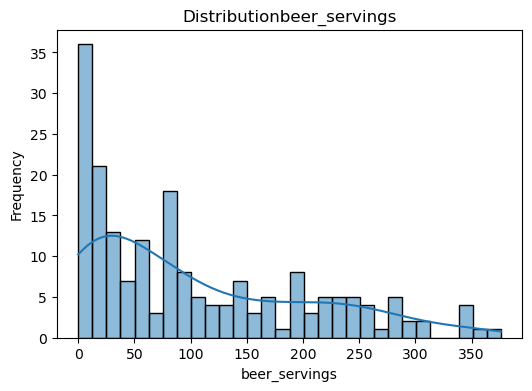

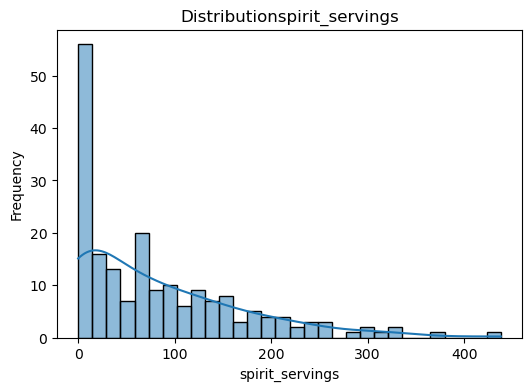

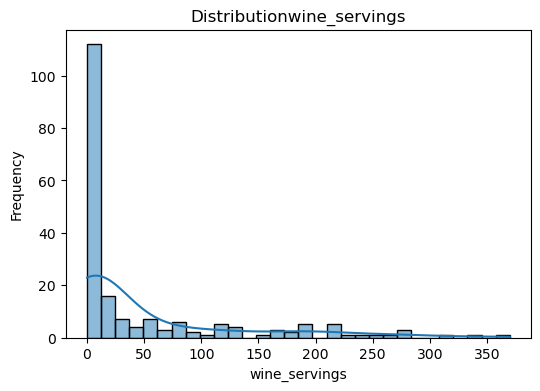

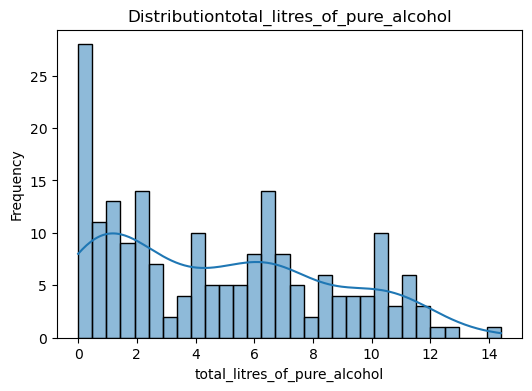

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True,bins=30)
    plt.title(f'Distribution{col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

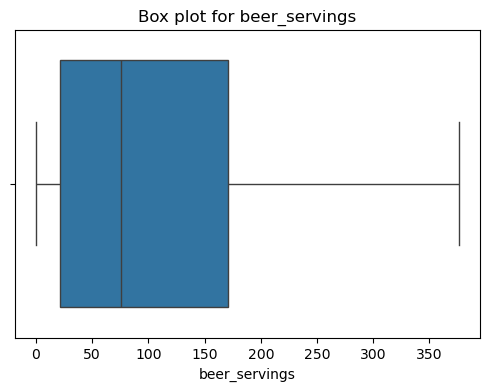

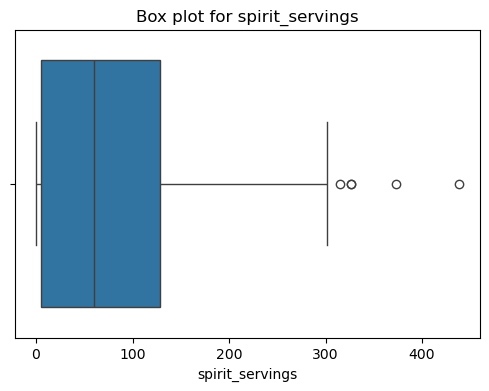

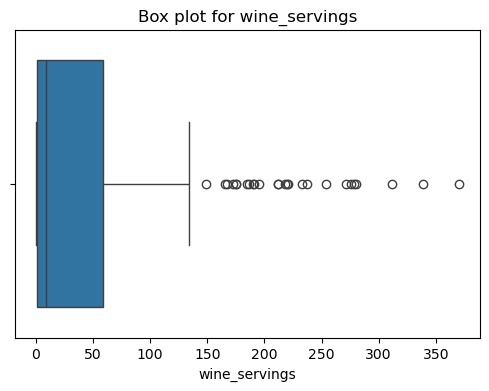

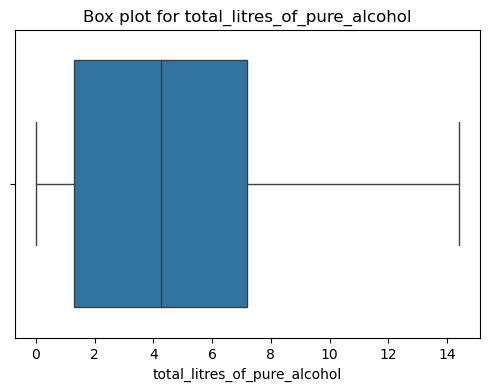

In [12]:
#boxplot
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(f'Box plot for {col}')
    plt.show()

Outlier Capping

In [13]:
#percentile capping - since the data is right skewed 
outlier_cols = ['spirit_servings','wine_servings']

for col in outlier_cols:
    lower = np.quantile(data[col],0.01)
    upper = np.quantile(data[col],0.95)
    data[col]=data[col].clip(lower,upper)

In [14]:
data.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,103.917098,78.927461,45.818653,4.739119
std,98.580146,78.273272,70.246480,3.757996
min,0.000000,0.000000,0.000000,0.000000
25%,21.000000,5.000000,1.000000,1.300000
50%,76.000000,60.000000,9.000000,4.250000
75%,171.000000,128.000000,59.000000,7.200000
max,376.000000,252.800000,225.800000,14.400000


In [15]:
data['continent'].value_counts()

continent
Africa           53
Europe           45
Asia             44
North America    23
Oceania          16
South America    12
Name: count, dtype: int64

In [16]:
data = data.drop('country',axis=1)

In [17]:
X = data.drop('total_litres_of_pure_alcohol',axis=1)
y = data['total_litres_of_pure_alcohol']

In [18]:
#X = pd.get_dummies(X,columns=['continent'])

OHE

In [19]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

encoded = ohe.fit_transform(X[['continent']])

In [20]:
encoded_df = pd.DataFrame(encoded.toarray(),columns=ohe.get_feature_names_out(['continent']))
X = pd.concat([X[['beer_servings','spirit_servings','wine_servings']],encoded_df],axis=1)

In [21]:
X.head()

,beer_servings,spirit_servings,wine_servings,continent_Africa,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,89.0,132.0,54.0,0.0,0.0,1.0,0.0,0.0,0.0
2,25.0,0.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0
3,245.0,138.0,225.8,0.0,0.0,1.0,0.0,0.0,0.0
4,217.0,57.0,45.0,1.0,0.0,0.0,0.0,0.0,0.0


In [22]:
#train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

DecisionTreeRegressor

In [23]:
#Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeRegressor(random_state=42)

dt_params = {
    'max_depth': [None,3,5,7,10],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

In [24]:
#GridSearchCV
grid_dt = GridSearchCV(dt,dt_params,cv=5,scoring='r2')
grid_dt.fit(X_train,y_train)
print('Best parameter for Decision Tree :',grid_dt.best_params_)

Best parameter for Decision Tree : {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [25]:
y_pred_dt = grid_dt.best_estimator_.predict(X_test)
r2_dt = r2_score(y_test,y_pred_dt)
print(r2_dt)

0.7666212705693984


Linear Regressor

In [26]:
#scailing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [28]:
y_pred_lr = lr.predict(X_test_scaled)
print(r2_score(y_test,y_pred_lr))

0.8835911524792335


Exporting 

In [29]:
import pickle

pickle.dump(lr,open('model/model.pkl','wb'))
pickle.dump(scaler,open('model/scaler.pkl','wb'))
pickle.dump(ohe,open('model/ohe.pkl','wb'))
